# Ejemplo práctico durante la clase (17 feb)

In [52]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create a dataset
# Let´s build the values lists
value_n_list = ['Andrew', 'Phillip', 'John',"Rose","Lau", "Maye", "Mara", "Sandra","Jairo", "Marcela"]
print(value_n_list)

value_w_list = [50,         78,      91.5, 47, 70, 55, 60, 45, 67,87] # [kg]
value_h_list = [1.76,      1.87,     1.69, 1.80, 1.70, 1.68, 1.67, 1.57, 1.87, 1.65] # [m]
# value_bmi_list will be calculated: bmi = w/(h^2)
#value_bmi_list = [25,25,25] # init values [kg/m2]

# Let´s use a dictionary ({key:value})
# with the format {"str":list}
data_dict = {"name":value_n_list,
             "weight":value_w_list,
             "height":value_h_list} #,
              #"BMI":value_bmi_list}

print(data_dict)

# Turn a dictionary into a dataframe
df = pd.DataFrame(data_dict)

print(df)
# Call a variable
df

['Andrew', 'Phillip', 'John', 'Rose', 'Lau', 'Maye', 'Mara', 'Sandra', 'Jairo', 'Marcela']
{'name': ['Andrew', 'Phillip', 'John', 'Rose', 'Lau', 'Maye', 'Mara', 'Sandra', 'Jairo', 'Marcela'], 'weight': [50, 78, 91.5, 47, 70, 55, 60, 45, 67, 87], 'height': [1.76, 1.87, 1.69, 1.8, 1.7, 1.68, 1.67, 1.57, 1.87, 1.65]}
      name  weight  height
0   Andrew    50.0    1.76
1  Phillip    78.0    1.87
2     John    91.5    1.69
3     Rose    47.0    1.80
4      Lau    70.0    1.70
5     Maye    55.0    1.68
6     Mara    60.0    1.67
7   Sandra    45.0    1.57
8    Jairo    67.0    1.87
9  Marcela    87.0    1.65


,name,weight,height
0,Andrew,50.0,1.76
1,Phillip,78.0,1.87
2,John,91.5,1.69
3,Rose,47.0,1.80
4,Lau,70.0,1.70
5,Maye,55.0,1.68
6,Mara,60.0,1.67
7,Sandra,45.0,1.57
8,Jairo,67.0,1.87
9,Marcela,87.0,1.65


Agregando datos

In [53]:
from faker import Faker
import numpy as np
import pandas as pd

# Initialize Faker with 'es_ES' locale
faker = Faker('es_ES')

# Number of additional records needed
num_additional_records = 9990

# Generate 9,990 single Spanish names
additional_names = [faker.first_name() for _ in range(num_additional_records)]

# Define parameters for weight generation
mean_weight = 65  # kg
std_dev_weight = 10  # kg
min_weight = 45 # kg
max_weight = 90 # kg

# Generate 9,990 weight values and clip them
additional_weights = np.random.normal(loc=mean_weight, scale=std_dev_weight, size=num_additional_records)
additional_weights = np.clip(additional_weights, min_weight, max_weight)

# Define parameters for height generation (using previous context's mean and std_dev if not specified)
mean_height = 1.70  # m
std_dev_height = 0.1  # m
min_height = 1.46 # m
max_height = 2.00 # m

# Generate 9,990 height values and clip them
additional_heights = np.random.normal(loc=mean_height, scale=std_dev_height, size=num_additional_records)
additional_heights = np.clip(additional_heights, min_height, max_height)

# Create a new DataFrame for the additional records
additional_data_dict = {
    'name': additional_names,
    'weight': additional_weights,
    'height': additional_heights
}
df_additional = pd.DataFrame(additional_data_dict)

# Assuming 'df' currently holds the initial 10 records
# If 'df' has been modified elsewhere, ensure to re-initialize it to the original 10 records
# For this task, I will concatenate with the existing 'df' variable in the kernel.

# Concatenate the original df with the additional DataFrame
df = pd.concat([df, df_additional], ignore_index=True)

print("DataFrame 'df' has been successfully expanded.")
print(f"New shape of df: {df.shape}")

DataFrame 'df' has been successfully expanded.
New shape of df: (10000, 3)


In [54]:
df

,name,weight,height
0,Andrew,50.000000,1.760000
1,Phillip,78.000000,1.870000
2,John,91.500000,1.690000
3,Rose,47.000000,1.800000
4,Lau,70.000000,1.700000
...,...,...,...
9995,León,60.837848,1.564564
9996,Eulalia,72.498989,1.805888
9997,Mercedes,60.461730,1.729242
9998,Ale,54.714123,1.648311


In [55]:
# prompt: Con DataFrame df: Para agregar otra columna

#Si uno hace una operación directamente en una columna, esta operación se va a realizar en todo
#Aqui voy a crear una nueva columna que se llama bmi teniendo encuenta los valores de las columnas weight y heigh

df['bmi'] = df['weight'] / (df['height'] ** 2)
df
#entre 18 y 25 es normal el imc normal de lo contrario fuera del rango normal



,name,weight,height,bmi
0,Andrew,50.000000,1.760000,16.141529
1,Phillip,78.000000,1.870000,22.305471
2,John,91.500000,1.690000,32.036693
3,Rose,47.000000,1.800000,14.506173
4,Lau,70.000000,1.700000,24.221453
...,...,...,...,...
9995,León,60.837848,1.564564,24.853489
9996,Eulalia,72.498989,1.805888,22.230554
9997,Mercedes,60.461730,1.729242,20.219438
9998,Ale,54.714123,1.648311,20.138225


In [56]:
import sys
!{sys.executable} -m pip install faker

In [57]:
# Define a function to determine health condition
def determine_health_condition(bmi):
    if 18.0 <= bmi <= 25.0:
        return 'peso normal'
    if bmi<18.0:
     return "bajo peso"
    if bmi>25.0:
      return "sobrepeso"

# Aplicar la función a la columna
df["health_condition"] = df["bmi"].apply(determine_health_condition)
df

,name,weight,height,bmi,health_condition
0,Andrew,50.000000,1.760000,16.141529,bajo peso
1,Phillip,78.000000,1.870000,22.305471,peso normal
2,John,91.500000,1.690000,32.036693,sobrepeso
3,Rose,47.000000,1.800000,14.506173,bajo peso
4,Lau,70.000000,1.700000,24.221453,peso normal
...,...,...,...,...,...
9995,León,60.837848,1.564564,24.853489,peso normal
9996,Eulalia,72.498989,1.805888,22.230554,peso normal
9997,Mercedes,60.461730,1.729242,20.219438,peso normal
9998,Ale,54.714123,1.648311,20.138225,peso normal


Agregando columnas

In [58]:
#Agregando columnas
apellidos=10000
df['apellido'] = [faker.last_name() for _ in range(apellidos)]
df


,name,weight,height,bmi,health_condition,apellido
0,Andrew,50.000000,1.760000,16.141529,bajo peso,Capdevila
1,Phillip,78.000000,1.870000,22.305471,peso normal,Almansa
2,John,91.500000,1.690000,32.036693,sobrepeso,Quiroga
3,Rose,47.000000,1.800000,14.506173,bajo peso,Castilla
4,Lau,70.000000,1.700000,24.221453,peso normal,Jiménez
...,...,...,...,...,...,...
9995,León,60.837848,1.564564,24.853489,peso normal,Ballesteros
9996,Eulalia,72.498989,1.805888,22.230554,peso normal,Palomares
9997,Mercedes,60.461730,1.729242,20.219438,peso normal,Prieto
9998,Ale,54.714123,1.648311,20.138225,peso normal,Moliner


In [59]:
edades=10000
df['edad']=[faker.random_int(min=18, max=70) for _ in range(edades)]
df

,name,weight,height,bmi,health_condition,apellido,edad
0,Andrew,50.000000,1.760000,16.141529,bajo peso,Capdevila,59
1,Phillip,78.000000,1.870000,22.305471,peso normal,Almansa,59
2,John,91.500000,1.690000,32.036693,sobrepeso,Quiroga,32
3,Rose,47.000000,1.800000,14.506173,bajo peso,Castilla,46
4,Lau,70.000000,1.700000,24.221453,peso normal,Jiménez,21
...,...,...,...,...,...,...,...
9995,León,60.837848,1.564564,24.853489,peso normal,Ballesteros,48
9996,Eulalia,72.498989,1.805888,22.230554,peso normal,Palomares,40
9997,Mercedes,60.461730,1.729242,20.219438,peso normal,Prieto,49
9998,Ale,54.714123,1.648311,20.138225,peso normal,Moliner,63


Análisis Estadistico

In [60]:
round(df.describe(),3)

,weight,height,bmi,edad
count,10000.000,10000.000,10000.000,10000.000
mean,65.141,1.698,22.812,43.941
std,9.779,0.099,4.361,15.316
min,45.000,1.460,11.935,18.000
25%,58.423,1.629,19.687,31.000
50%,65.052,1.698,22.459,44.000
75%,71.744,1.766,25.611,57.000
max,91.500,2.000,42.222,70.000


**Media**=La media de weight es 65.029 kg, lo que indica que el peso promedio en tu conjunto de datos es aproximadamente 65 kg.

**Desviación estandar**: La desviación de 9.848 en el peso sugiere que la mayoría de las personas pesan entre 55kg y 75kg.

La desviación en edad (15.21) indica una alta diversidad generacional en la muestra.

**Cuartiles**

**Primer Cuartil**: El 25% de la población tiene, menos de 30 años y pesa menos de 58.2 kg

**Segundo caurtil:** Es el valor central; el 50% de las personas mide menos de 1.69 m y el otro 50% mide más. Como la mediana (1.698) es casi igual a la media (1.699), puede indicar una distribución normal/simétrica en la altura

**Tercer Cuartil**: El 75% de la muestra tiene un BMI inferior a 25.56. Esto significa que solo el 25% superior entra en categorías de sobrepeso o superior

**Máximo:**

El peso máximo es 91.5 kg y la altura máxima es 2.00 m





Histograma de cada columna

<Axes: >

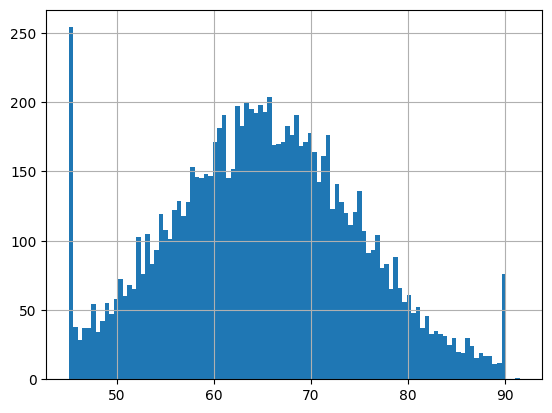

In [61]:
df["weight"].hist(bins=100)

<Axes: >

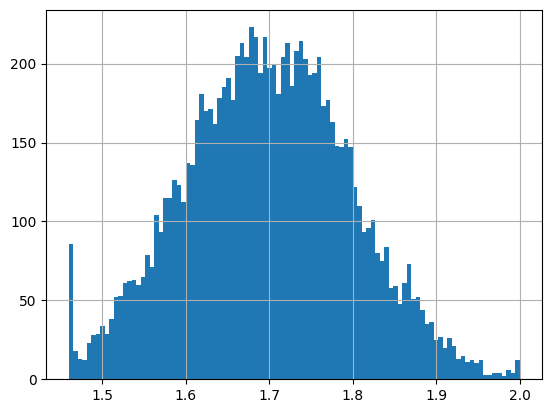

In [62]:

df["height"].hist(bins=100)

<Axes: >

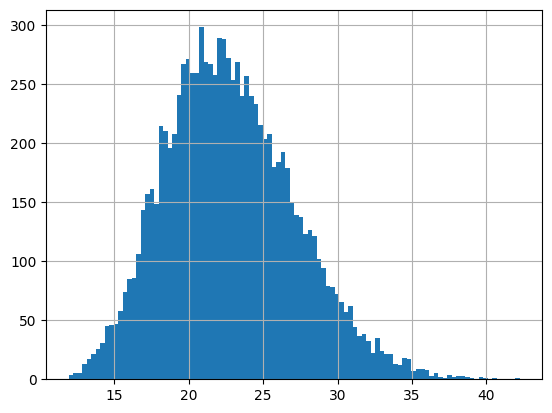

In [63]:

df["bmi"].hist(bins=100)

<Axes: >

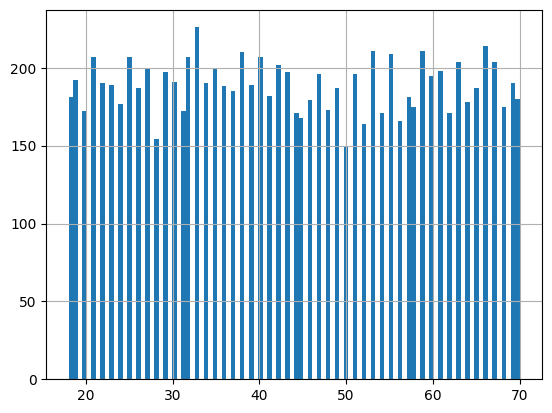

In [64]:
df["edad"].hist(bins=100)

Identificando el tipo de dato de cada columna

In [65]:
df["bmi"].dtype


dtype('float64')

In [66]:
df["name"].dtype


dtype('O')

In [67]:
df["edad"].dtype

dtype('int64')

In [68]:
df["weight"].dtype

dtype('float64')

In [69]:
#Cuando realizamos una matriz de correlación y el signo es negativo, la relación de las variables es inversa

#Que es un EDA (pasos)
#Buscar la operación de la correlación
#Consultar como hacer la matriz de correlación
#Incluir formulas como si estuvieran escritas en un tablero
#Consultar que es y como funciona la matriz de confusión (clasificación)
#Consultar metricas de desempeño par aregresión y clasificación

### Matriz de Correlación: Qué es y cómo se interpreta

Una **matriz de correlación** es una tabla que muestra los coeficientes de correlación entre muchas variables. Cada celda de la matriz muestra el coeficiente de correlación entre dos variables. Es una forma excelente de ver rápidamente las relaciones entre pares de variables en un conjunto de datos.

#### ¿Cómo se interpreta?

*   **Diagonal principal:** Siempre tendrá valores de 1, ya que una variable siempre está perfectamente correlacionada consigo misma.
*   **Simetría:** La matriz es simétrica. El coeficiente de correlación entre la Variable A y la Variable B es el mismo que entre la Variable B y la Variable A.
*   **Valores:**
    *   **Valores cercanos a 1:** Indican una fuerte correlación positiva. A medida que una variable aumenta, la otra también aumenta.
    *   **Valores cercanos a -1:** Indican una fuerte correlación negativa. A medida que una variable aumenta, la otra disminuye.
    *   **Valores cercanos a 0:** Indican una correlación lineal débil o nula. No hay una relación lineal clara entre las variables.

#### ¿Por qué es útil?

*   **Identificación rápida de relaciones:** Permite identificar de un vistazo qué variables están relacionadas y la fuerza de esa relación.
*   **Selección de características:** Ayuda a entender si hay variables redundantes (muy correlacionadas entre sí) o si existen relaciones importantes para modelos predictivos.
*   **Detección de multicolinealidad:** En modelos de regresión, una alta correlación entre variables predictoras puede ser problemática (multicolinealidad).

Para visualizar la matriz de correlación de manera efectiva, a menudo se utiliza un **mapa de calor (heatmap)**.

### Correlación: Qué es, su fórmula y cómo funciona

La **correlación** es una medida estadística que indica la dirección y la fuerza de la relación lineal entre dos variables numéricas. Es decir, nos dice si dos variables tienden a cambiar juntas y en qué medida lo hacen.

#### Dirección de la Correlación:

*   **Correlación Positiva (mayor que 0):** Cuando una variable aumenta, la otra también tiende a aumentar. (Ej: a mayor estatura, mayor peso).
*   **Correlación Negativa (menor que 0):** Cuando una variable aumenta, la otra tiende a disminuir. (Ej: a mayor número de horas estudiando, menor número de errores en un examen).
*   **Sin Correlación (cercana a 0):** No hay una relación lineal aparente entre las variables. Los cambios en una variable no están relacionados con los cambios en la otra. (Ej: la estatura de una persona y el número de su calzado en países diferentes).

#### Fuerza de la Correlación:

La fuerza de la correlación se mide por el valor absoluto del coeficiente de correlación, que varía entre -1 y 1:

*   **Valores cercanos a 1 o -1:** Indican una relación lineal fuerte.
*   **Valores cercanos a 0:** Indican una relación lineal débil o inexistente.

#### Coeficiente de Correlación de Pearson (r)

La fórmula más común para medir la correlación lineal es el Coeficiente de Correlación de Pearson. Su fórmula es la siguiente:

$$\rho_{X,Y} = \frac{cov(X,Y)}{\sigma_X \sigma_Y} = \frac{E[(X - \mu_X)(Y - \mu_Y)]}{\sigma_X \sigma_Y}$$

Donde:
*   $\rho_{X,Y}$ (rho) es el coeficiente de correlación de Pearson entre las variables X e Y.
*   $cov(X,Y)$ es la covarianza de X e Y.
*   $\sigma_X$ es la desviación estándar de X.
*   $\sigma_Y$ es la desviación estándar de Y.
*   $E$ es el valor esperado (o la media).
*   $\mu_X$ y $\mu_Y$ son las medias de X e Y, respectivamente.

En términos más simples, la fórmula se puede expresar como:

$$r = \frac{n\sum XY - (\sum X)(\sum Y)}{\sqrt{[n\sum X^2 - (\sum X)^2][n\sum Y^2 - (\sum Y)^2]}}$$

Donde:
*   $n$ es el número de pares de datos.
*   $\sum XY$ es la suma de los productos de cada par de valores X e Y.
*   $\sum X$ y $\sum Y$ son las sumas de los valores de X e Y, respectivamente.
*   $\sum X^2$ y $\sum Y^2$ son las sumas de los cuadrados de los valores de X e Y, respectivamente.

#### ¿Cómo funciona?

La correlación de Pearson evalúa la relación lineal entre dos variables. Básicamente, compara la covarianza (cómo varían X e Y juntas) con el producto de sus desviaciones estándar (cuánto varían X e Y por separado). Al normalizar la covarianza de esta manera, el coeficiente de correlación se mantiene entre -1 y 1, independientemente de la escala de las variables.

**Importante:** La correlación no implica causalidad. Una correlación alta entre dos variables no significa necesariamente que una cause la otra. Podría haber una tercera variable oculta (confusora) que influya en ambas, o la relación podría ser puramente coincidente.

Matriz de Correlación:


,weight,height,bmi,edad
weight,1.000000,0.010564,0.780217,-0.010207
height,0.010564,1.000000,-0.606551,-0.005323
bmi,0.780217,-0.606551,1.000000,-0.003605
edad,-0.010207,-0.005323,-0.003605,1.000000


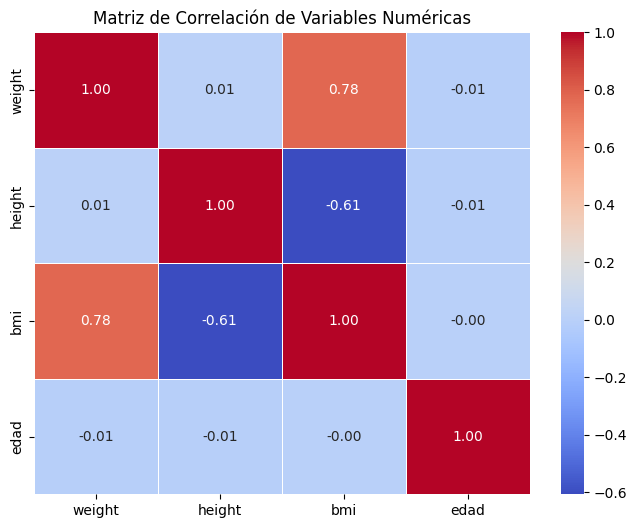

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar solo las columnas numéricas para la matriz de correlación
# Las columnas 'name', 'health_condition', 'apellido' son categóricas y no son adecuadas para la correlación de Pearson
columnas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()

# Calcular la matriz de correlación
correlation_matrix = df[columnas_numericas].corr()

# Mostrar la matriz de correlación
print('Matriz de Correlación:')
display(correlation_matrix)

# Visualizar la matriz de correlación con un mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

### Pasos del Análisis Exploratorio de Datos (EDA)

El EDA es un enfoque inicial para resumir las características principales de un conjunto de datos, a menudo con métodos visuales. Los pasos generales incluyen:

1.  **Entendimiento del problema y los datos:** Definir qué preguntas se quieren responder y cómo los datos se relacionan con ellas. Familiarizarse con el origen y el contexto de los datos.

2.  **Limpieza de datos:**
    *   Manejo de valores faltantes.
    *   Detección y tratamiento de valores atípicos (outliers).
    *   Corrección de errores (tipográficos, inconsistencias).
    *   Estandarización y normalización de datos si es necesario.

3.  **Análisis de la estructura de los datos:**
    *   Identificación de tipos de datos (numéricos, categóricos, fechas).
    *   Verificación de la unicidad y cardinalidad de las columnas.
    *   Ajuste de tipos de datos si son incorrectos.

4.  **Estadísticas descriptivas:**
    *   Cálculo de medidas de tendencia central (media, mediana, moda).
    *   Cálculo de medidas de dispersión (desviación estándar, varianza, rango, cuartiles).
    *   Análisis de la forma de la distribución (asimetría, curtosis).
    *   Uso de funciones como `df.describe()`.

5.  **Visualización de datos (gráficos):**
    *   **Variables univariantes:** Histogramas, diagramas de caja (box plots), diagramas de barras.
    *   **Variables bivariantes:** Diagramas de dispersión (scatter plots), gráficos de barras apiladas/agrupadas, box plots por categoría.
    *   **Matrices de correlación:** Para visualizar relaciones lineales entre múltiples variables numéricas.

6.  **Identificación de patrones y tendencias:**
    *   Búsqueda de relaciones y correlaciones.
    *   Identificación de estacionalidad o tendencias en series temporales.
    *   Segmentación de datos para encontrar patrones en subgrupos.

7.  **Comunicación de resultados:** Presentar los hallazgos clave de forma clara y concisa, utilizando gráficos y resúmenes para informar los próximos pasos en el análisis o modelado.

### Matriz de Confusión: ¿Qué es?

Una **matriz de confusión** es una tabla que se utiliza para evaluar el rendimiento de un algoritmo de clasificación. Permite visualizar el desempeño del algoritmo, especialmente cuando hay clases desequilibradas o cuando los costos de diferentes tipos de errores varían.

Aquí te explico sus componentes principales, utilizando el ejemplo de una clasificación binaria (dos clases, por ejemplo, 'positivo' y 'negativo'):

*   **Verdaderos Positivos (VP):** Son los casos en los que el modelo predijo correctamente la clase positiva.
*   **Verdaderos Negativos (VN):** Son los casos en los que el modelo predijo correctamente la clase negativa.
*   **Falsos Positivos (FP):** Son los casos en los que el modelo predijo incorrectamente la clase positiva (cuando en realidad era negativa). Esto se conoce como error de 'Tipo I'.
*   **Falsos Negativos (FN):** Son los casos en los que el modelo predijo incorrectamente la clase negativa (cuando en realidad era positiva). Esto se conoce como error de 'Tipo II'.

La matriz se organiza de la siguiente manera:

| | Predicción Positiva | Predicción Negativa |
| :------------------ | :------------------ | :------------------ |
| **Real Positivo** | Verdaderos Positivos (VP) | Falsos Negativos (FN) |
| **Real Negativo** | Falsos Positivos (FP) | Verdaderos Negativos (VN) |


Al analizar los valores en estas cuatro categorías, puedes calcular métricas como la precisión, el recall (sensibilidad), la especificidad y el F1-score, que te dan una imagen más completa de cómo funciona tu modelo. En resumen, te ayuda a entender no solo cuántas predicciones fueron correctas en general, sino también *dónde* el modelo se equivocó y *qué tipo* de errores cometió.

### Preparación de Datos para Clasificación y Matriz de Confusión

Para poder generar una matriz de confusión, necesitamos:
1.  **Definir las características (X)** y la **variable objetivo (y)**.
2.  **Codificar la variable objetivo** si es categórica (en este caso, `health_condition`).
3.  **Dividir los datos** en conjuntos de entrenamiento y prueba (`X_train`, `X_test`, `y_train`, `y_test`).
4.  **Entrenar un modelo** de clasificación.
5.  **Realizar predicciones** (`y_pred`).

Aquí realizaremos estos pasos y utilizaremos un modelo de `LogisticRegression` para demostrar cómo obtener `y_test` y `y_pred`.

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Definir características (X) y variable objetivo (y)
# Excluir 'name', 'apellido' ya que son categóricas no numéricas y 'bmi' porque es derivada y podría causar multicolinealidad con 'weight' y 'height'.
X = df[['weight', 'height', 'edad']]
y = df['health_condition']

# 2. Codificar la variable objetivo categórica a numérica
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 3. Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de y_test: {y_test.shape}")

Dimensiones de X_train: (7000, 3)
Dimensiones de X_test: (3000, 3)
Dimensiones de y_train: (7000,)
Dimensiones de y_test: (3000,)


In [73]:
# 4. Entrenar un modelo de clasificación (Logistic Regression como ejemplo)
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# 5. Realizar predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

print("Modelo de Regresión Logística entrenado y predicciones realizadas.")

# Ahora podemos calcular y_test y y_pred para la matriz de confusión

Modelo de Regresión Logística entrenado y predicciones realizadas.


### Graficando la Matriz de Confusión

Con `y_test` (etiquetas verdaderas) y `y_pred` (etiquetas predichas) disponibles, podemos generar la matriz de confusión y visualizarla para evaluar el rendimiento del modelo.

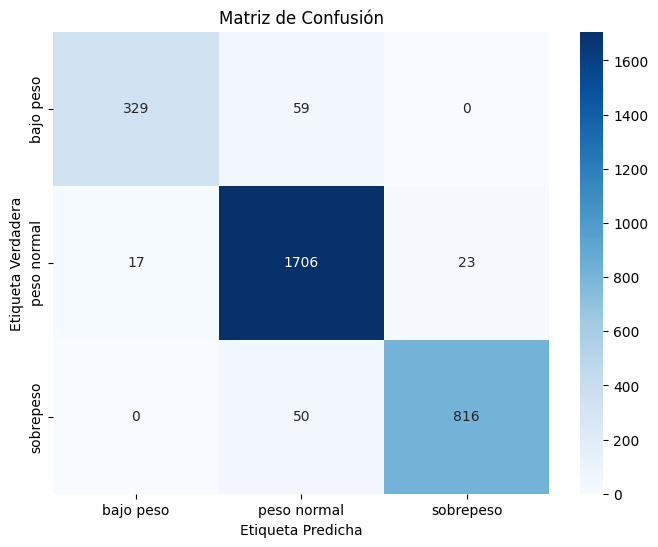


Reporte de Clasificación:
              precision    recall  f1-score   support

   bajo peso       0.95      0.85      0.90       388
 peso normal       0.94      0.98      0.96      1746
   sobrepeso       0.97      0.94      0.96       866

    accuracy                           0.95      3000
   macro avg       0.95      0.92      0.94      3000
weighted avg       0.95      0.95      0.95      3000



In [74]:
# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Verdadera')
plt.title('Matriz de Confusión')
plt.show()

# Opcional: Mostrar un reporte de clasificación más detallado
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

### Métricas de Desempeño para Clasificación y Regresión

#### Métricas para Modelos de Clasificación

Los modelos de clasificación predicen una categoría o clase. Las métricas evalúan qué tan bien el modelo asigna las instancias a sus clases correctas.

1.  **Exactitud (Accuracy)**
    *   **Qué es:** La proporción de predicciones correctas sobre el total de predicciones. Es la métrica más intuitiva, pero puede ser engañosa en conjuntos de datos desequilibrados.
    *   **Fórmula:**
        $$Accuracy = \frac{VP + VN}{VP + VN + FP + FN}$$
    *   **Interpretación:** Un valor más alto indica un mejor rendimiento general del modelo.

2.  **Precisión (Precision)**
    *   **Qué es:** La proporción de verdaderos positivos (VP) entre todos los resultados positivos predichos por el modelo. Responde a la pregunta: "De todas las veces que el modelo predijo positivo, ¿cuántas fueron realmente positivas?"
    *   **Fórmula:**
        $$Precision = \frac{VP}{VP + FP}$$
    *   **Interpretación:** Una alta precisión significa un bajo número de falsos positivos (FP).

3.  **Sensibilidad/Exhaustividad (Recall/Sensitivity)**
    *   **Qué es:** La proporción de verdaderos positivos (VP) entre todos los casos que son realmente positivos. Responde a la pregunta: "De todas las veces que la clase era realmente positiva, ¿cuántas logró identificar correctamente el modelo?"
    *   **Fórmula:**
        $$Recall = \frac{VP}{VP + FN}$$
    *   **Interpretación:** Un alto recall significa un bajo número de falsos negativos (FN).

4.  **Puntuación F1 (F1-Score)**
    *   **Qué es:** La media armónica de la Precisión y el Recall. Es útil cuando se busca un equilibrio entre precisión y exhaustividad, especialmente en clases desequilibradas.
    *   **Fórmula:**
        $$F1\text{-}Score = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$
    *   **Interpretación:** Un valor alto indica que el modelo tiene buena precisión y buen recall.

#### Métricas para Modelos de Regresión

Los modelos de regresión predicen un valor numérico continuo. Las métricas evalúan la diferencia entre los valores predichos y los valores reales.

1.  **Error Absoluto Medio (MAE - Mean Absolute Error)**
    *   **Qué es:** El promedio de las diferencias absolutas entre las predicciones y los valores reales. Mide la magnitud promedio de los errores sin considerar su dirección.
    *   **Fórmula:**
        $$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$
        Donde: $y_i$ es el valor real, $\hat{y}_i$ es el valor predicho, y $n$ es el número de observaciones.
    *   **Interpretación:** Un MAE más bajo indica un mejor rendimiento. Es robusto a los valores atípicos.

2.  **Error Cuadrático Medio (MSE - Mean Squared Error)**
    *   **Qué es:** El promedio de los cuadrados de los errores. Penaliza más los errores grandes que el MAE, ya que eleva al cuadrado las diferencias.
    *   **Fórmula:**
        $$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$
    *   **Interpretación:** Un MSE más bajo indica un mejor rendimiento. Es sensible a los valores atípicos.

3.  **Raíz del Error Cuadrático Medio (RMSE - Root Mean Squared Error)**
    *   **Qué es:** La raíz cuadrada del MSE. Es popular porque el resultado está en las mismas unidades que la variable objetivo, lo que facilita la interpretación.
    *   **Fórmula:**
        $$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$
    *   **Interpretación:** Un RMSE más bajo indica un mejor rendimiento. Al igual que el MSE, es sensible a los valores atípicos.

4.  **Coeficiente de Determinación (R-squared o $R^2$)**
    *   **Qué es:** Mide la proporción de la varianza en la variable dependiente que es predecible a partir de las variables independientes. Indica qué tan bien los puntos de datos se ajustan a la línea de regresión (cuán bien explica el modelo la variabilidad de los datos).
    *   **Fórmula:**
        $$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$
        Donde $\bar{y}$ es la media de los valores reales.
    *   **Interpretación:** Un valor de $R^2$ entre 0 y 1. Un $R^2$ más cercano a 1 indica que el modelo explica una mayor proporción de la varianza de la variable objetivo, lo que generalmente significa un mejor ajuste.